# TUTORIAL: Class Model and Class Ensemble

* [How to use the class `Model`](#first)
    * [Model initialization](#second)
    * [Model forecast](#third)
* [Ensemble of class Model](#fourth)
    * [Ensemble initialization](#fifth)
    * [Ensemble forecast](#sixth)
    * [Visualizing the ensemble](#seventh)


# How to use the class `Model` <a class="anchor" id="first"></a>

### 1. Initialise a model from `models_physical` or `models_data_driven` using the defaults parameters  <a class="anchor" id="second"></a>
The available models are:
* Lorenz63
* Rijke
* Annular
* Van der Pol
* Kuramoto-Sivashinsky
* ESN
* POD-ESN
* Lorenz96

Under the hood every `Model` composes two pieces: a `HistoryTracker` (the pre-allocated, grow-on-demand state/time buffer behind `hist`, `hist_t`, `current_state` and `update_history()`) and an `Integrator` strategy — continuous models define `time_derivative(t, psi, **params)` and are advanced with scipy's `solve_ivp`, while discrete maps (ESN, Kuramoto-Sivashinsky, LinearModel) define `time_step(Nt)` directly.


In [1]:
from romda.models.physical import VdP  as TheModel

case = TheModel()  # If no arguments, the class is initialized with the default parameters


### 2. Forecast the model as a single case  <a class="anchor" id="third"></a>

The forecast of the model is taken care by the `Integrator` class. Different models use different integrators:
- `<class 'integrator.IVPIntegrator'>`: models defined in state-space form as intial value problems (e.g, Rijke, Lorenz63, VdP)

    $\dfrac{d \psi}{d t} = F(\psi, t, x)$
- `<class 'integrator.DiscreteIntegrator'>`: models with discrete time stepping (e.g, ESN, KS)

    $\psi(t+\Delta t) = \psi(t) + G(\psi(t))\Delta t$



In [2]:
print(f'Model {case.__class__.__name__} uses {case.integrator.__class__.__name__} for time integration.')

Model VdP uses IVPIntegrator for time integration.


In [3]:
import time

Nt_forecast = int( case.t_transient / case.dt)

t1 = time.time()
state, t_ = case.time_integrate(Nt_forecast)
case.update_history(state[1:], t_[1:], reset=True)

single_case_time = time.time() - t1
print('Elapsed time = ', str(single_case_time))



Elapsed time =  0.12101340293884277


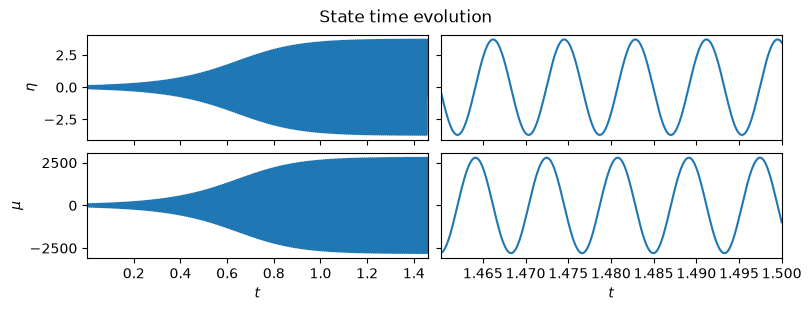

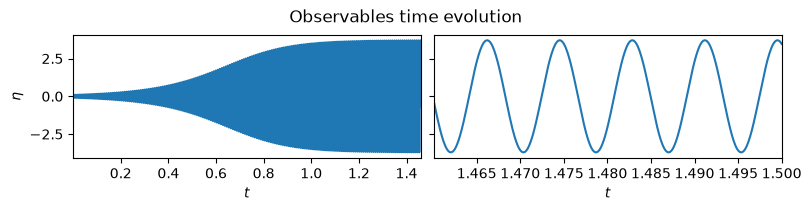

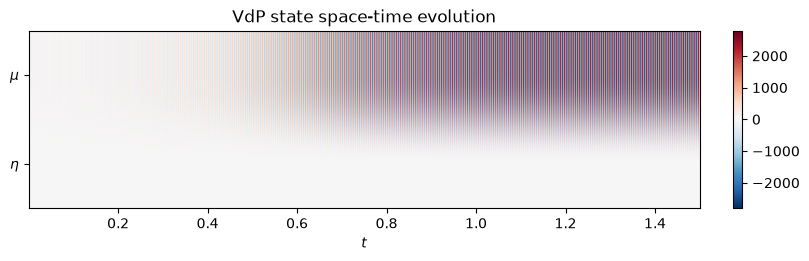

In [4]:
import matplotlib.pyplot as plt

case.visualize_history()


# Ensemble Class  <a class="anchor" id="fourth"></a>

### 1. Initialize ensemble <a class="anchor" id="fifth"></a>

In [5]:
from romda.estimators import EnSRKF

m = 10
ensemble = EnSRKF(parent_model=case.copy(),
                    m=m, 
                    std_phi=1., 
                    est_alpha=case.params[-2:], # Select the ensemble varying parameters
                    std_alpha=0.1,  # the parameters uncertainty can also be defined individually in a dictionary
                    distribution_alpha='uniform'
                   )


### 2. Forecast ensemble <a class="anchor" id="sixth"></a>
The Model time_integrate function is parallelized to save computation time. We compare the ensemble forecast with a for loop forecast. 


{'beta': 70.0, 'zeta': 60.0, 'kappa': 4.0}

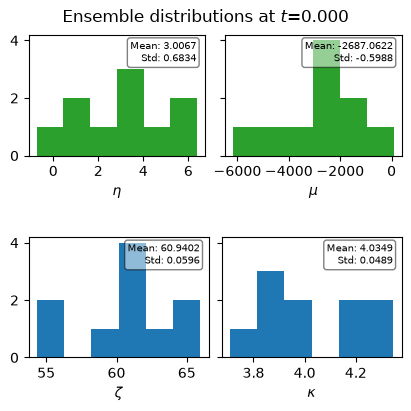

In [6]:
ensemble.visualize_state(time_indices=[0, -1], 
                         max_modes=4,
                         reference_a=1.);
ensemble.model.alpha

### 3. Visualizing the ensemble <a class="anchor" id="seventh"></a>

In [7]:
import time

# Warm-up call: the first forecast pays the multiprocessing pool start-up cost, so it is not timed.
ensemble.forecast_step(t_end=ensemble.current_time + case.t_transient, close=False)

t1 = time.time()
n_tests = 10
for _ in range(n_tests):
    t_end = ensemble.current_time + case.t_transient
    ensemble.forecast_step(t_end=t_end, close=False) # This is the main time integration step for the ensemble forecast 
ensemble_case_time = (time.time() - t1) / n_tests

print(f'Average elapsed ensemble time over {n_tests} tests = {ensemble_case_time}')
print(f'Average elapsed time per ensemble member = {ensemble_case_time / m}')

Initializing multiprocessing pool for IVPIntegrator with m=10 and 10 pools.


Average elapsed ensemble time over 10 tests = 0.1740652561187744
Average elapsed time per ensemble member = 0.01740652561187744


We compare the running time of the ensemble forecast with a for-loop implementation. 

In [8]:
from romda.models.integrator import ivp_forecast_helper, IVPIntegrator
import numpy as np

test_parallel = True  # Set to True to test the parallelization speed-up against for-loop implementation.
if type(ensemble.model.integrator) is IVPIntegrator:

    if not test_parallel:
        #skipp the parallelization test
        print('Skipping parallelization speed-up test.')
    else:
        print('Testing parallelization speed-up against for-loop implementation...')

        pm = ensemble.model

        # Same workload as one forecast_step: one window of Nt steps, per-member parameters.
        Nt = int(case.t_transient / pm.dt)
        t_all = np.round(pm.current_time + np.arange(Nt + 1) * pm.dt, pm.precision_t)
        psi0 = pm.current_state
        args = pm.governing_eqns_params
        alpha_list = pm.get_alpha()

        # --- Solve ivp for each ensemble member individually ---
        t1 = time.time()
        for mi in range(ensemble.m):
            ivp_forecast_helper(y0=psi0[:, mi],
                                fun=pm.time_derivative,
                                t=t_all,
                                params={**args, **alpha_list[mi]})
        ensemble_for_time = time.time() - t1

        print(f'Elapsed ensemble for loop time = {ensemble_for_time} >> {ensemble_case_time}.')
        print(f'Speed-up factor = {ensemble_for_time/ensemble_case_time}.')
else:
    print(f'Currently, no parallelization is available for {type(ensemble.model.integrator)}.')


Testing parallelization speed-up against for-loop implementation...


Elapsed ensemble for loop time = 0.9667313098907471 >> 0.1740652561187744.
Speed-up factor = 5.55384418146659.


In [9]:
ensemble.model.hist.shape


(165001, 4, 10)

/storage0/anovoama/romda/src/estimators/ensembles.py:926: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig1.legend(loc='center', bbox_to_anchor=(0.5, 1.05), ncol=6, frameon=False)


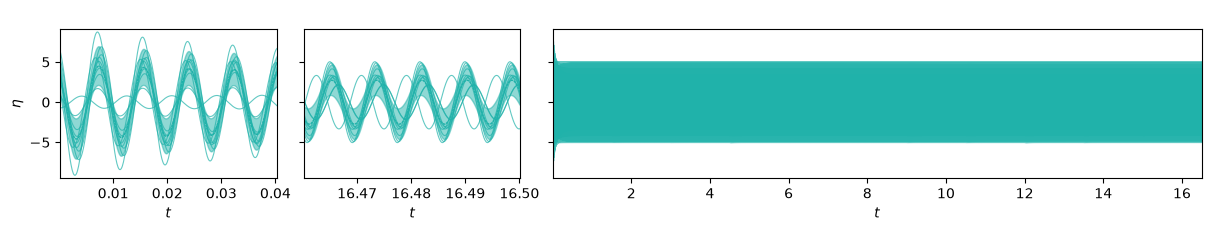

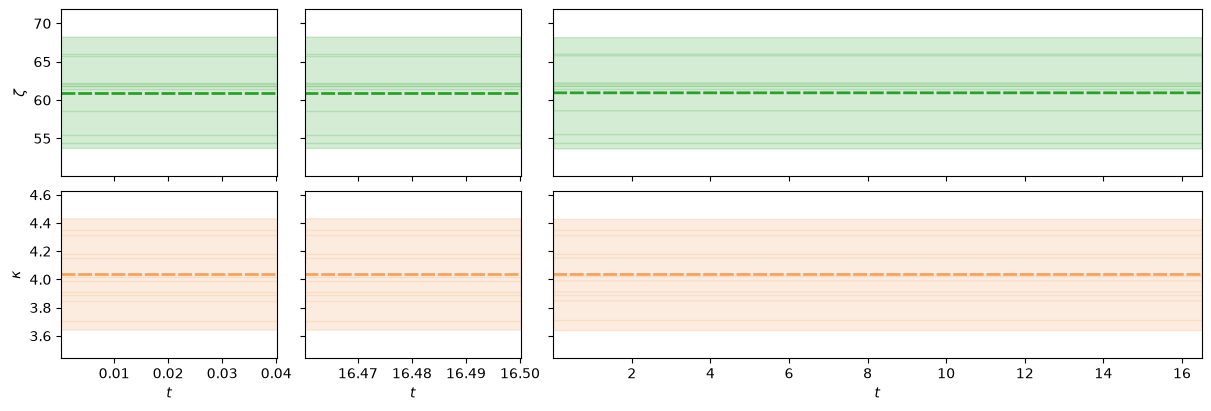

In [10]:
ensemble.visualize_history(plot_members=True, 
                           dims='all', 
                           reference_t=1., 
                           reference_a=dict(tau=0.002))

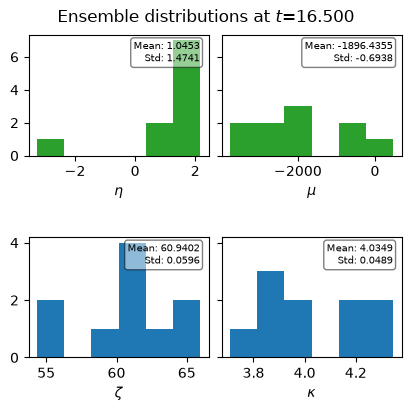

In [11]:
ensemble.visualize_state(time_indices=[0, -1], 
                         max_modes=4,
                         reference_a=1.)

In [12]:

Nt = 5*int(ensemble.model.t_CR // ensemble.model.dt)
y_hist = ensemble.model.get_observable_hist(loc="all", Nt=Nt)
t_hist = ensemble.model.hist_t[-Nt:]


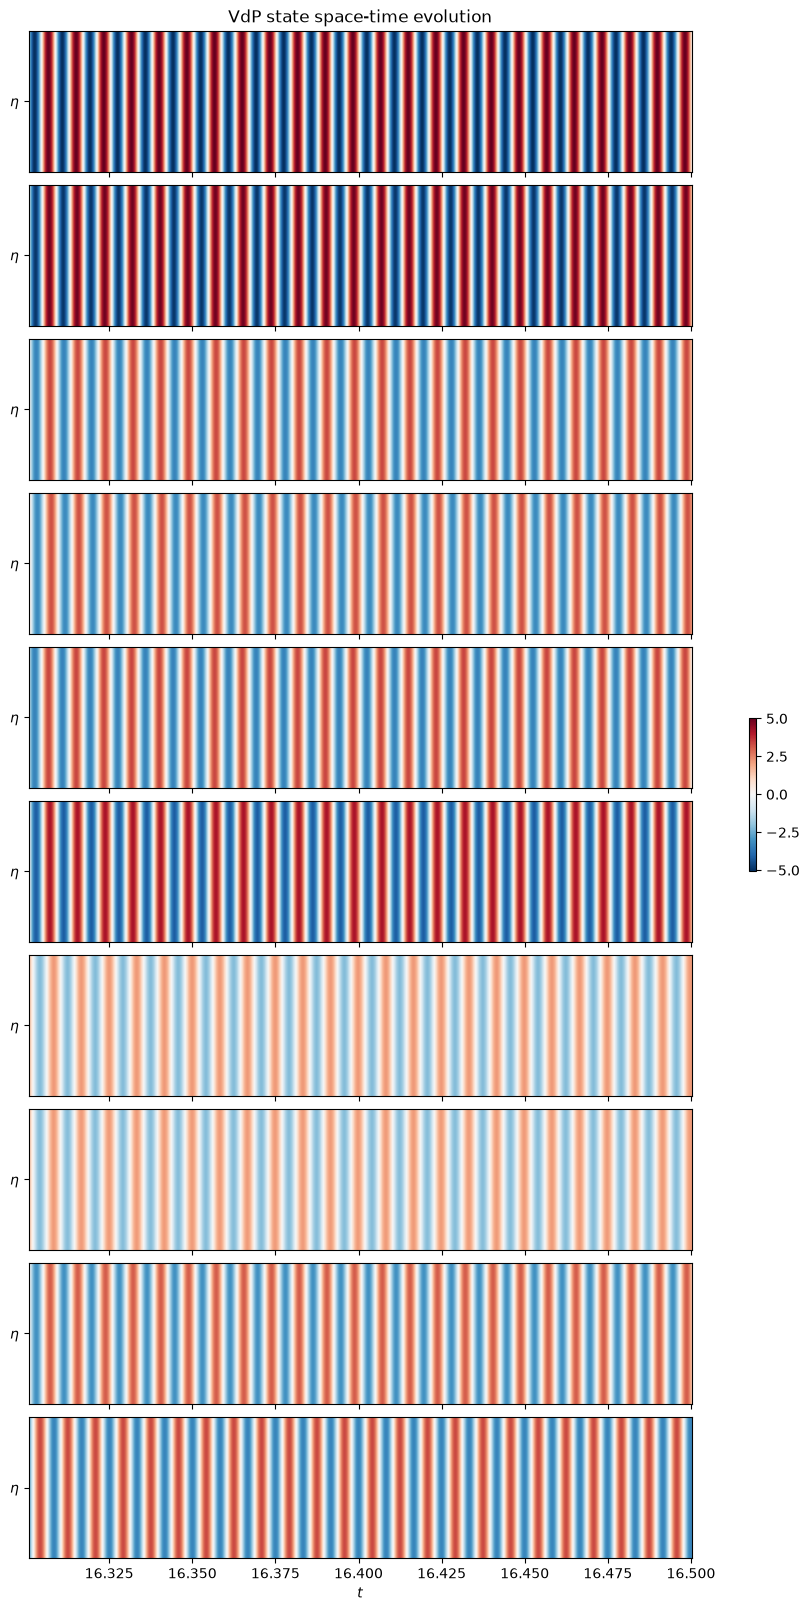

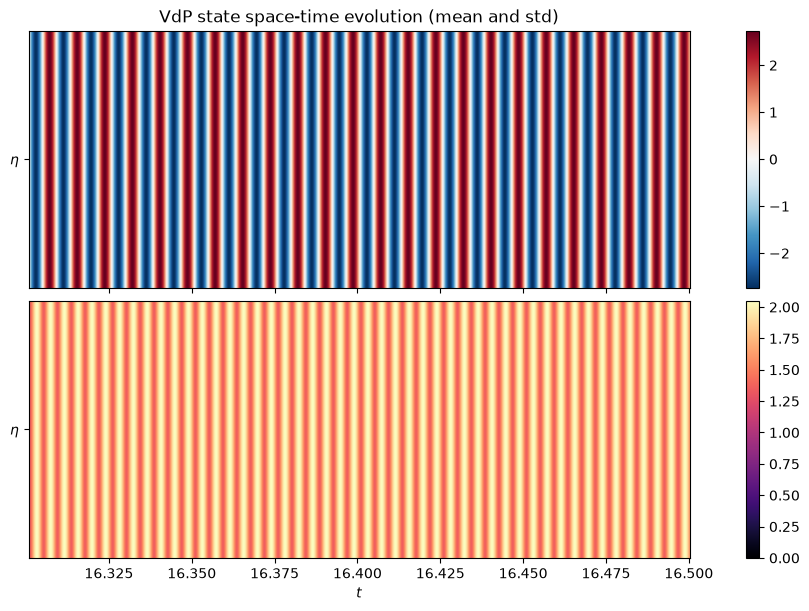

In [13]:

ensemble.model.visualize_spatiotemporal_hist(averaged=False, y_hist=y_hist, t=t_hist)
ensemble.model.visualize_spatiotemporal_hist(averaged=True, y_hist=y_hist, t=t_hist)